# Análisis de Datos IV

In [1]:
import pandas as pd

In [2]:
# Importar base de datos de exoplanetas
data_url = "https://exoplanetarchive.ipac.caltech.edu/cgi-bin/nstedAPI/nph-nstedAPI?table=cumulative&select=koi_period,koi_sma,koi_smass&format=csv"
df_0 = pd.read_csv(data_url)

In [3]:
# Eliminación de los renglones que contienen valores NaN
df_limpia=df_0.dropna().reset_index(drop=True)

In [4]:
def filtro(base,col,factor):
  '''Función que elimina datos de las colas de la columna indicada de una base de datos determinando el indice intercuartílico
y seleccionando elementos que están por encima del tercer cuartil a una distancia indice_intercuartil*factor y elementos que están por abajo del segundo cuartil a la misma distancia'''
  indice_intercuartil=base[col].quantile(0.75)-base[col].quantile(0.25)
  filtro_inferior=base[col]>base[col].quantile(0.25)-(indice_intercuartil*factor)
  filtro_superior=base[col]<base[col].quantile(0.75)+(indice_intercuartil*factor)
  return base[filtro_inferior & filtro_superior]

In [5]:
# Filtramos datos para quitar las colas de las tres variables de interés
df_l1=filtro(df_limpia,'koi_period',2)
df_l2=filtro(df_l1,'koi_sma',2)
df_1=filtro(df_l2,'koi_smass',2)

In [6]:
df_1.head()

,koi_period,koi_sma,koi_smass
0,9.488036,0.0853,0.919
1,54.418383,0.2734,0.919
2,19.899140,0.1419,0.961
3,1.736952,0.0267,0.836
4,2.525592,0.0374,1.095


Matriz de Correlación de Pearson

In [7]:
df_1.corr()

,koi_period,koi_sma,koi_smass
koi_period,1.000000,0.975239,-0.034591
koi_sma,0.975239,1.000000,0.058032
koi_smass,-0.034591,0.058032,1.000000


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Matriz de Correlación de Pearson')

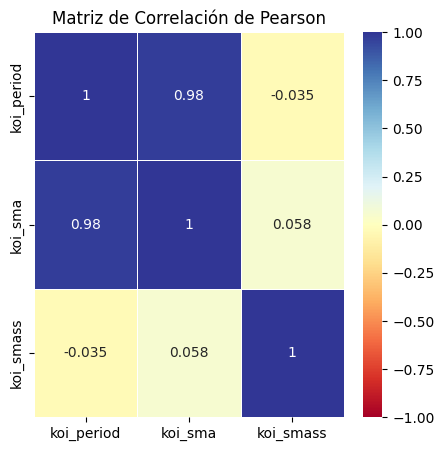

In [9]:
from prompt_toolkit.shortcuts import set_title
plt.figure(figsize=(5,5))
eje_0=sns.heatmap(df_1.corr(), vmin=-1,vmax=1,annot=True,cmap="RdYlBu", linewidths=0.5)
eje_0.set_title('Matriz de Correlación de Pearson')

Tercera ley de Kepler:  $$T^2=\frac{k a^3}{M}$$, con $T$ como el período orbital, $a$ como el semieje mayor, $M$ como la masa de la estrella y $k$ una constante. Tomando el logaritmo natural en ambos lados de la ecuación anterior, obtenemos: $$2 \log T=\log k+3\log a-\log M.$$ Despejando el logaritmo de la masa $$\log M=\log k+3\log a-2 \log T$$

Conversión a Unidades del Sistema Internacional y toma del Logaritmo natural

In [10]:
import numpy as np

In [23]:
df_2=df_1.copy()

In [24]:
df_2['ln_masa']=(df_1['koi_smass'].apply(lambda x: x*1.988416*10**30)).apply(np.log)

In [25]:
df_2['ln_semi']=(df_1['koi_sma'].apply(lambda x: x*149597870700)).apply(np.log)

In [26]:
df_2['ln_periodo']=(df_1['koi_period'].apply(lambda x: x*86400)).apply(np.log)

In [27]:
df_2.head()

,koi_period,koi_sma,koi_smass,ln_masa,ln_semi,ln_periodo
0,9.488036,0.0853,0.919,69.680422,23.269636,13.616775
1,54.418383,0.2734,0.919,69.680422,24.434397,15.363445
2,19.899140,0.1419,0.961,69.725110,23.778584,14.357419
3,1.736952,0.0267,0.836,69.585764,22.108125,11.918875
4,2.525592,0.0374,1.095,69.855645,22.445132,12.293218


In [28]:
df_3=df_2.drop(['koi_period','koi_sma','koi_smass'],axis=1)

In [29]:
df_3.head()

,ln_masa,ln_semi,ln_periodo
0,69.680422,23.269636,13.616775
1,69.680422,24.434397,15.363445
2,69.725110,23.778584,14.357419
3,69.585764,22.108125,11.918875
4,69.855645,22.445132,12.293218


Ahora podemos verificar que existe una correlación lineal entre los logaritmos del período y el semieje

Text(0.5, 1.0, 'Matriz de Correlación de Pearson')

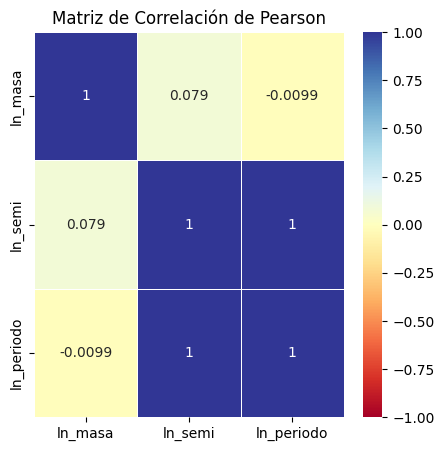

In [30]:
plt.figure(figsize=(5,5))
eje_0=sns.heatmap(df_3.corr(), vmin=-1,vmax=1,annot=True,cmap="RdYlBu", linewidths=0.5)
eje_0.set_title('Matriz de Correlación de Pearson')

Ejemplo de Regresión Lineal

Primer paso: Identificar las variables independientes y dependientes

In [31]:
X=df_3[['ln_semi','ln_periodo']] # Variables independientes
Y=df_3['ln_masa'] # Variable dependientes

Segundo paso: dividir nuestros datos en conjuntos de entrenamiento y de prueba

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_entrenamiento, X_prueba, Y_entrenamiento, Y_prueba=train_test_split(X,Y,test_size=0.3, shuffle=True)

Tercer paso: Hacer la regresión lineal múltiple

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
lr=LinearRegression()
lr.fit(X_entrenamiento,Y_entrenamiento)

LinearRegression()

Coeficientes de la regresión lineal

In [37]:
# de acuerdo con la tercera ley de Kepler, estos valores deben ser 3 y -2
lr.coef_

array([ 2.93740046, -1.95861181])

In [38]:
# log k
lr.intercept_

np.float64(27.997933898385824)